<a href="https://colab.research.google.com/github/bagchibijoyini-a11y/cerebro_2026/blob/main/prob1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# PS-01: Multi-Person Conversation Conflict Analysis
# ============================================================

!pip -q install transformers torch pandas numpy matplotlib seaborn scikit-learn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

In [2]:
# Sentiment analysis
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

# Emotion classification
emotion_model = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

...

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [3]:
conversation = [
    ("Alice", "I don't think we should do it this way."),
    ("Bob", "You always have a problem with everything I suggest."),
    ("Alice", "That is not true. You never listen to what I say."),
    ("Charlie", "Can we please discuss this calmly?"),
    ("Bob", "Why should I listen when nobody respects my opinion?"),
    ("Alice", "This conversation is pointless."),
    ("Bob", "Fine. Do whatever you want."),
    ("Charlie", "I think we should take a break and discuss this later.")
]

df = pd.DataFrame(conversation, columns=["speaker", "message"])

df["turn"] = range(1, len(df) + 1)

df

,speaker,message,turn
0,Alice,I don't think we should do it this way.,1
1,Bob,You always have a problem with everything I su...,2
2,Alice,That is not true. You never listen to what I say.,3
3,Charlie,Can we please discuss this calmly?,4
4,Bob,Why should I listen when nobody respects my op...,5
5,Alice,This conversation is pointless.,6
6,Bob,Fine. Do whatever you want.,7
7,Charlie,I think we should take a break and discuss thi...,8


In [4]:
def get_sentiment(text):
    result = sentiment_model(text)[0]

    return pd.Series({
        "sentiment": result["label"],
        "sentiment_score": result["score"]
    })

sentiment_results = df["message"].apply(get_sentiment)

df = pd.concat([df, sentiment_results], axis=1)

df

,speaker,message,turn,sentiment,sentiment_score
0,Alice,I don't think we should do it this way.,1,negative,0.752090
1,Bob,You always have a problem with everything I su...,2,negative,0.838784
2,Alice,That is not true. You never listen to what I say.,3,negative,0.802399
3,Charlie,Can we please discuss this calmly?,4,neutral,0.776042
4,Bob,Why should I listen when nobody respects my op...,5,negative,0.818819
5,Alice,This conversation is pointless.,6,negative,0.883449
6,Bob,Fine. Do whatever you want.,7,neutral,0.656619
7,Charlie,I think we should take a break and discuss thi...,8,neutral,0.755661


In [5]:
def get_emotions(text):
    results = emotion_model(text)[0]

    scores = {
        r["label"]: r["score"]
        for r in results
    }

    return pd.Series({
        "anger": scores.get("anger", 0),
        "annoyance": scores.get("annoyance", 0),
        "disapproval": scores.get("disapproval", 0),
        "disappointment": scores.get("disappointment", 0),
        "sadness": scores.get("sadness", 0),
        "fear": scores.get("fear", 0),
        "neutral": scores.get("neutral", 0),
        "joy": scores.get("joy", 0)
    })

emotion_results = df["message"].apply(get_emotions)

df = pd.concat([df, emotion_results], axis=1)

df

,speaker,message,turn,sentiment,sentiment_score,anger,annoyance,disapproval,disappointment,sadness,fear,neutral,joy
0,Alice,I don't think we should do it this way.,1,negative,0.752090,0.009657,0.053178,0.851512,0.013577,0.003639,0.001125,0.148290,0.003056
1,Bob,You always have a problem with everything I su...,2,negative,0.838784,0.007865,0.148882,0.205554,0.045329,0.005263,0.000695,0.572043,0.001101
2,Alice,That is not true. You never listen to what I say.,3,negative,0.802399,0.028676,0.135566,0.775025,0.016903,0.003549,0.000860,0.180799,0.001724
3,Charlie,Can we please discuss this calmly?,4,neutral,0.776042,0.003787,0.016176,0.006319,0.002692,0.002569,0.001522,0.400690,0.002389
4,Bob,Why should I listen when nobody respects my op...,5,negative,0.818819,0.032100,0.177314,0.054399,0.020179,0.002871,0.000971,0.292413,0.000793
5,Alice,This conversation is pointless.,6,negative,0.883449,0.066570,0.455397,0.381750,0.038636,0.002837,0.000522,0.224936,0.001603
6,Bob,Fine. Do whatever you want.,7,neutral,0.656619,0.003259,0.014236,0.007554,0.001230,0.001109,0.000725,0.239578,0.002784
7,Charlie,I think we should take a break and discuss thi...,8,neutral,0.755661,0.001166,0.018966,0.073655,0.006412,0.001111,0.000983,0.447157,0.005198


In [6]:
patterns = {
    "blame": [
        r"\byou always\b",
        r"\byou never\b",
        r"\bbecause of you\b",
        r"\byour fault\b",
        r"\byou caused\b"
    ],

    "hostility": [
        r"\bidiot\b",
        r"\bstupid\b",
        r"\bshut up\b",
        r"\bhate\b",
        r"\bcan't stand\b"
    ],

    "defensiveness": [
        r"\bthat's not true\b",
        r"\bi didn't\b",
        r"\bnot my fault\b",
        r"\bi never\b",
        r"\bdon't blame me\b"
    ],

    "withdrawal": [
        r"\bfine\b",
        r"\bwhatever\b",
        r"\bforget it\b",
        r"\bnever mind\b",
        r"\bi'm done\b",
        r"\bleave me alone\b",
        r"\bpointless\b"
    ],

    "negative_framing": [
        r"\bterrible\b",
        r"\bawful\b",
        r"\bpointless\b",
        r"\bworst\b",
        r"\bproblem\b",
        r"\bwrong\b"
    ]
}


def detect_pattern(text, pattern_list):
    text = text.lower()

    return int(
        any(re.search(pattern, text) for pattern in pattern_list)
    )


for category, pattern_list in patterns.items():
    df[category] = df["message"].apply(
        lambda x: detect_pattern(x, pattern_list)
    )

df

,speaker,message,turn,sentiment,sentiment_score,anger,annoyance,disapproval,disappointment,sadness,fear,neutral,joy,blame,hostility,defensiveness,withdrawal,negative_framing
0,Alice,I don't think we should do it this way.,1,negative,0.752090,0.009657,0.053178,0.851512,0.013577,0.003639,0.001125,0.148290,0.003056,0,0,0,0,0
1,Bob,You always have a problem with everything I su...,2,negative,0.838784,0.007865,0.148882,0.205554,0.045329,0.005263,0.000695,0.572043,0.001101,1,0,0,0,1
2,Alice,That is not true. You never listen to what I say.,3,negative,0.802399,0.028676,0.135566,0.775025,0.016903,0.003549,0.000860,0.180799,0.001724,1,0,0,0,0
3,Charlie,Can we please discuss this calmly?,4,neutral,0.776042,0.003787,0.016176,0.006319,0.002692,0.002569,0.001522,0.400690,0.002389,0,0,0,0,0
4,Bob,Why should I listen when nobody respects my op...,5,negative,0.818819,0.032100,0.177314,0.054399,0.020179,0.002871,0.000971,0.292413,0.000793,0,0,0,0,0
5,Alice,This conversation is pointless.,6,negative,0.883449,0.066570,0.455397,0.381750,0.038636,0.002837,0.000522,0.224936,0.001603,0,0,0,1,1
6,Bob,Fine. Do whatever you want.,7,neutral,0.656619,0.003259,0.014236,0.007554,0.001230,0.001109,0.000725,0.239578,0.002784,0,0,0,1,0
7,Charlie,I think we should take a break and discuss thi...,8,neutral,0.755661,0.001166,0.018966,0.073655,0.006412,0.001111,0.000983,0.447157,0.005198,0,0,0,0,0


In [7]:
df["conflict_score"] = (
    0.25 * df["anger"] +
    0.15 * df["annoyance"] +
    0.15 * df["disapproval"] +
    0.15 * df["blame"] +
    0.10 * df["hostility"] +
    0.10 * df["defensiveness"] +
    0.05 * df["negative_framing"] +
    0.05 * df["withdrawal"]
)

df["conflict_score"] = df["conflict_score"].clip(0, 1)

df[[
    "turn",
    "speaker",
    "message",
    "conflict_score"
]]

,turn,speaker,message,conflict_score
0,1,Alice,I don't think we should do it this way.,0.138118
1,2,Bob,You always have a problem with everything I su...,0.255132
2,3,Alice,That is not true. You never listen to what I say.,0.293758
3,4,Charlie,Can we please discuss this calmly?,0.004321
4,5,Bob,Why should I listen when nobody respects my op...,0.042782
5,6,Alice,This conversation is pointless.,0.242215
6,7,Bob,Fine. Do whatever you want.,0.054083
7,8,Charlie,I think we should take a break and discuss thi...,0.014185


In [8]:
def classify_conflict(score):
    if score < 0.20:
        return "Low"
    elif score < 0.40:
        return "Moderate"
    elif score < 0.65:
        return "High"
    else:
        return "Severe"

df["conflict_level"] = df["conflict_score"].apply(
    classify_conflict
)

df[[
    "turn",
    "speaker",
    "message",
    "conflict_score",
    "conflict_level"
]]

,turn,speaker,message,conflict_score,conflict_level
0,1,Alice,I don't think we should do it this way.,0.138118,Low
1,2,Bob,You always have a problem with everything I su...,0.255132,Moderate
2,3,Alice,That is not true. You never listen to what I say.,0.293758,Moderate
3,4,Charlie,Can we please discuss this calmly?,0.004321,Low
4,5,Bob,Why should I listen when nobody respects my op...,0.042782,Low
5,6,Alice,This conversation is pointless.,0.242215,Moderate
6,7,Bob,Fine. Do whatever you want.,0.054083,Low
7,8,Charlie,I think we should take a break and discuss thi...,0.014185,Low


In [9]:
df["rolling_conflict"] = (
    df["conflict_score"]
    .rolling(window=3, min_periods=1)
    .mean()
)

df["escalation_change"] = (
    df["rolling_conflict"].diff().fillna(0)
)

df["escalating"] = df["escalation_change"] > 0.05

df[[
    "turn",
    "speaker",
    "conflict_score",
    "rolling_conflict",
    "escalation_change",
    "escalating"
]]

,turn,speaker,conflict_score,rolling_conflict,escalation_change,escalating
0,1,Alice,0.138118,0.138118,0.000000,False
1,2,Bob,0.255132,0.196625,0.058507,True
2,3,Alice,0.293758,0.229002,0.032378,False
3,4,Charlie,0.004321,0.184403,-0.044599,False
4,5,Bob,0.042782,0.113620,-0.070783,False
5,6,Alice,0.242215,0.096439,-0.017181,False
6,7,Bob,0.054083,0.113027,0.016587,False
7,8,Charlie,0.014185,0.103494,-0.009532,False


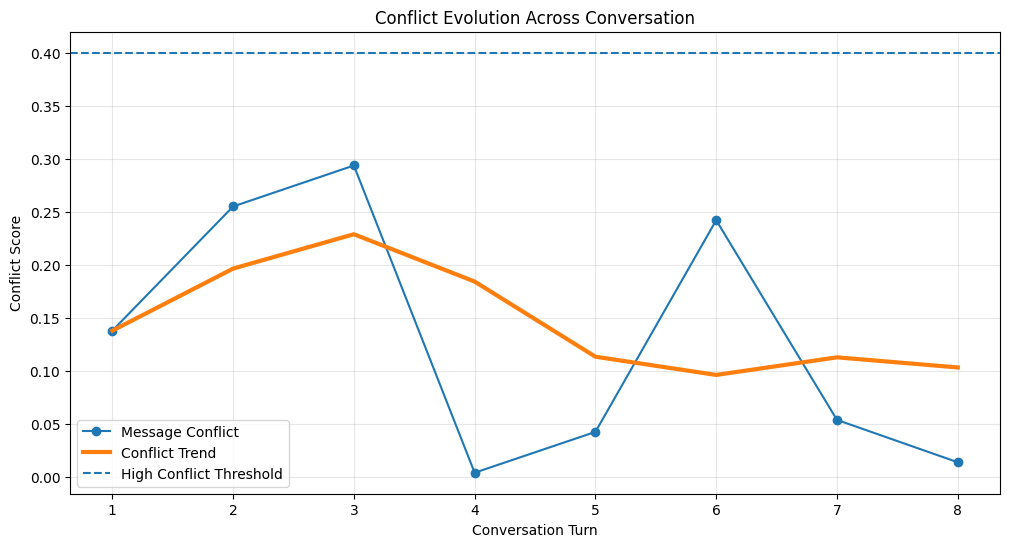

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["turn"],
    df["conflict_score"],
    marker="o",
    label="Message Conflict"
)

plt.plot(
    df["turn"],
    df["rolling_conflict"],
    linewidth=3,
    label="Conflict Trend"
)

plt.axhline(
    0.40,
    linestyle="--",
    label="High Conflict Threshold"
)

plt.xlabel("Conversation Turn")
plt.ylabel("Conflict Score")
plt.title("Conflict Evolution Across Conversation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

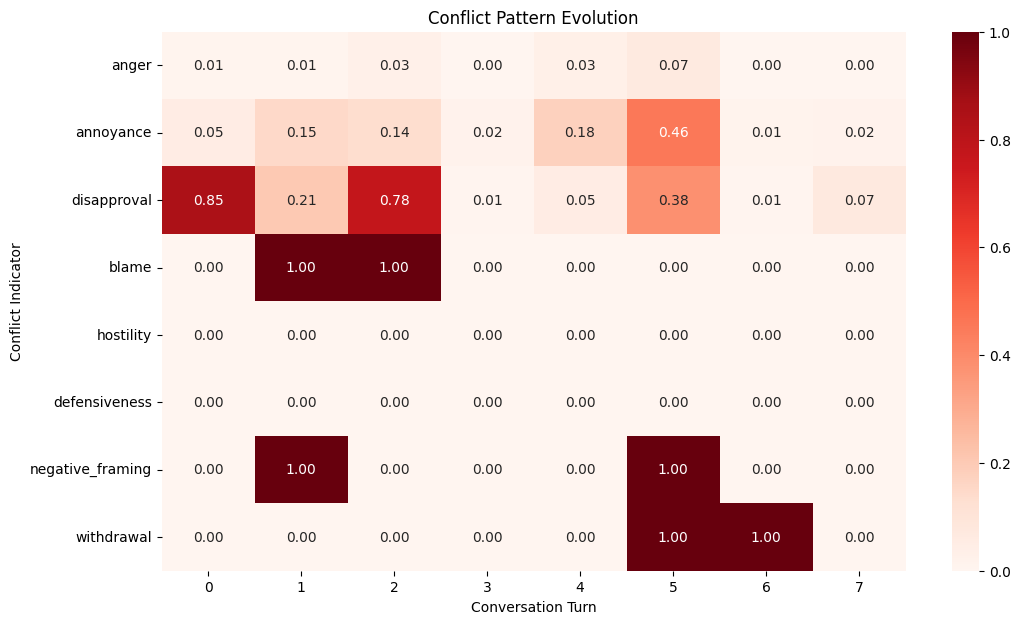

In [11]:
indicator_columns = [
    "anger",
    "annoyance",
    "disapproval",
    "blame",
    "hostility",
    "defensiveness",
    "negative_framing",
    "withdrawal"
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    df[indicator_columns].T,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.xlabel("Conversation Turn")
plt.ylabel("Conflict Indicator")
plt.title("Conflict Pattern Evolution")

plt.show()

In [12]:
speaker_analysis = df.groupby("speaker").agg({
    "conflict_score": "mean",
    "anger": "mean",
    "blame": "mean",
    "hostility": "mean",
    "defensiveness": "mean",
    "withdrawal": "mean",
    "negative_framing": "mean"
}).round(3)

speaker_analysis

,conflict_score,anger,blame,hostility,defensiveness,withdrawal,negative_framing
speaker,,,,,,,
Alice,0.225,0.035,0.333,0.0,0.0,0.333,0.333
Bob,0.117,0.014,0.333,0.0,0.0,0.333,0.333
Charlie,0.009,0.002,0.000,0.0,0.0,0.000,0.000


In [13]:
peak_turn = df.loc[
    df["conflict_score"].idxmax()
]

print("Peak Conflict Point")
print("-------------------")
print("Turn:", peak_turn["turn"])
print("Speaker:", peak_turn["speaker"])
print("Message:", peak_turn["message"])
print("Conflict Score:", round(peak_turn["conflict_score"], 3))
print("Conflict Level:", peak_turn["conflict_level"])

Peak Conflict Point
-------------------
Turn: 3
Speaker: Alice
Message: That is not true. You never listen to what I say.
Conflict Score: 0.294
Conflict Level: Moderate


In [14]:
mean_conflict = df["conflict_score"].mean()
max_conflict = df["conflict_score"].max()

early_conflict = df.head(
    max(1, len(df)//3)
)["conflict_score"].mean()

late_conflict = df.tail(
    max(1, len(df)//3)
)["conflict_score"].mean()

change = late_conflict - early_conflict

print("========== CONVERSATION ANALYSIS ==========")

print(f"Average Conflict Score : {mean_conflict:.3f}")
print(f"Peak Conflict Score    : {max_conflict:.3f}")
print(f"Early Conflict         : {early_conflict:.3f}")
print(f"Late Conflict          : {late_conflict:.3f}")
print(f"Overall Change         : {change:+.3f}")

if change > 0.10:
    print("\nPattern: Conflict escalated over the conversation.")
elif change < -0.10:
    print("\nPattern: Conflict decreased over the conversation.")
else:
    print("\nPattern: Conflict remained relatively stable.")

========== CONVERSATION ANALYSIS ==========
Average Conflict Score : 0.131
Peak Conflict Score    : 0.294
Early Conflict         : 0.197
Late Conflict          : 0.034
Overall Change         : -0.162

Pattern: Conflict decreased over the conversation.
